## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

# Topic 1 : [Car Prices Dataset]

## Problem Statement

[its hard to know the right price of a used car because cars have many different features . The goal of this project is to build a Machine Learning model that predicts car prices based on these features.]

## Data Info
Data Source :https://www.kaggle.com/datasets/sidharth178/car-prices-dataset/data

## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| ID | Integer | Unique identifier for each car entry |
| Price | Numerical | The market price of the car (Target Column) |
| Levy | Numerical / Text | Tax or duty amount imposed on the vehicle |
| Manufacturer | Categorical | The brand or maker of the car (e.g., Toyota, BMW) |
| Model | Categorical | The specific model name of the vehicle |
| Prod. year | Integer | The manufacturing year of the vehicle |
| Category | Categorical | The body style/type of the vehicle (e.g., SUV, Sedan) |
| Leather interior | Binary / Boolean | Indicates whether the car has a leather interior (Yes/No) |
| Fuel type | Categorical | The type of fuel used (e.g., Petrol, Diesel, Hybrid) |
| Engine volume | Numerical / Text | Engine capacity in liters (may include turbo info) |
| Mileage | Numerical / Text | Total distance driven by the car |
| Cylinders | Integer | Number of engine cylinders |
| Gear box type | Categorical | Transmission type (e.g., Automatic, Manual, Tiptronic) |
| Drive wheels | Categorical | Drivetrain configuration (e.g., Front, Rear, 4x4) |
| Doors | Categorical / Text | Number of doors on the vehicle |
| Wheel | Categorical | Steering wheel position (Left wheel / Right wheel) |
| Color | Categorical | Exterior color of the vehicle |
| Airbags | Integer | Total count of safety airbags in the car |

In [1]:
# start you EDA
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn import metrics
from sklearn.model_selection import KFold
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('./New folder/train.csv')
df.shape

(19237, 18)

In [3]:
df.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [4]:
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [6]:
df.isna().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [7]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [8]:
df.duplicated().sum()

np.int64(313)

In [9]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [10]:
df['Levy'].unique()

<ArrowStringArray>
[ '1399',  '1018',     '-',   '862',   '446',   '891',   '761',   '751',
   '394',  '1053',
 ...
  '1171',  '1365',  '1531',  '1590', '11706',  '2308',  '4860',  '1641',
  '1045',  '1901']
Length: 559, dtype: str

In [11]:
df['Levy'] = df['Levy'].replace('-', np.nan)

In [12]:
df['Levy'].isnull().sum()

np.int64(5709)

In [13]:
#################### اغيره اذا شلت النلز و سويت فل
# df['Levy'] = df['Levy'].astype(int)

In [14]:
df['Cylinders'].value_counts()

Cylinders
4.0     14159
6.0      3373
8.0       976
5.0       169
3.0       107
2.0        42
12.0       38
1.0        37
10.0       12
16.0        5
7.0         4
9.0         1
14.0        1
Name: count, dtype: int64

In [15]:
df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)
df['Mileage']

0        186005
1        192000
2        200000
3        168966
4         91901
          ...  
19232    300000
19233    161600
19234    116365
19235     51258
19236    186923
Name: Mileage, Length: 18924, dtype: int64

In [16]:
df['Doors'].value_counts()

Doors
04-May    18032
02-Mar      768
>5          124
Name: count, dtype: int64

In [17]:
df['Doors'] = df['Doors'].astype(str).str.strip()
doors_mapping = {
    '02-Mar': '2-3',
    '04-May': '4-5',
    '>5': '>5'  
}
df['Doors'] = df['Doors'].replace(doors_mapping)
df['Doors'].value_counts()

Doors
4-5    18032
2-3      768
>5       124
Name: count, dtype: int64

In [18]:
df['Engine volume']

0              3.5
1                3
2              1.3
3              2.5
4              1.3
           ...    
19232    2.0 Turbo
19233          2.4
19234            2
19235            2
19236          2.4
Name: Engine volume, Length: 18924, dtype: str

In [19]:
df['Turbo'] = df['Engine volume'].astype(str).str.contains('Turbo', case=False, na=False).astype(int)
df['Engine volume'] = df['Engine volume'].astype(str).str.replace('Turbo', '', case=False).str.strip()
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')
df[['Engine volume' , 'Turbo']] 

,Engine volume,Turbo
0,3.5,0
1,3.0,0
2,1.3,0
3,2.5,0
4,1.3,0
...,...,...
19232,2.0,1
19233,2.4,0
19234,2.0,0
19235,2.0,0


In [20]:
df['Turbo'].value_counts()

Turbo
0    17032
1     1892
Name: count, dtype: int64

In [21]:
print(df['Category'].value_counts())
print()
print()
print(df['Leather interior'].value_counts())
print()
print()
print(df['Fuel type'].value_counts())
print()
print()
print(df['Drive wheels'].value_counts())
print()
print()
print(df['Doors'].value_counts())
print()
print()
print(df['Wheel'].value_counts())
print()
print()
print(df['Color'].value_counts())

Category
Sedan          8600
Jeep           5378
Hatchback      2799
Minivan         633
Coupe           528
Universal       361
Microbus        299
Goods wagon     229
Pickup           51
Cabriolet        35
Limousine        11
Name: count, dtype: int64


Leather interior
Yes    13731
No      5193
Name: count, dtype: int64


Fuel type
Petrol            9944
Diesel            4001
Hybrid            3539
LPG                885
CNG                469
Plug-in Hybrid      85
Hydrogen             1
Name: count, dtype: int64


Drive wheels
Front    12695
4x4       3969
Rear      2260
Name: count, dtype: int64


Doors
4-5    18032
2-3      768
>5       124
Name: count, dtype: int64


Wheel
Left wheel          17471
Right-hand drive     1453
Name: count, dtype: int64


Color
Black            4944
White            4407
Silver           3729
Grey             2343
Blue             1376
Red               622
Green             321
Orange            252
Brown             185
Carnelian red     177
Go

In [22]:
df['Manufacturer'].unique()

<ArrowStringArray>
[        'LEXUS',     'CHEVROLET',         'HONDA',          'FORD',
       'HYUNDAI',        'TOYOTA', 'MERCEDES-BENZ',          'OPEL',
       'PORSCHE',           'BMW',          'JEEP',    'VOLKSWAGEN',
          'AUDI',       'RENAULT',        'NISSAN',        'SUBARU',
        'DAEWOO',           'KIA',    'MITSUBISHI',     'SSANGYONG',
         'MAZDA',           'GMC',          'FIAT',      'INFINITI',
    'ALFA ROMEO',        'SUZUKI',         'ACURA',       'LINCOLN',
           'VAZ',           'GAZ',       'CITROEN',    'LAND ROVER',
          'MINI',         'DODGE',      'CHRYSLER',        'JAGUAR',
         'ISUZU',         'SKODA',      'DAIHATSU',         'BUICK',
         'TESLA',      'CADILLAC',       'PEUGEOT',       'BENTLEY',
         'VOLVO',          'სხვა',         'HAVAL',        'HUMMER',
         'SCION',           'UAZ',       'MERCURY',           'ZAZ',
         'ROVER',          'SEAT',        'LANCIA',      'MOSKVICH',
      'MASERATI

In [23]:
(df['Manufacturer'] == 'სხვა').sum()

np.int64(2)

In [24]:
df['Manufacturer'] = df['Manufacturer'].replace('სხვა', 'Other')

In [25]:
df['Model'].nunique()

1590

In [26]:
df['Model'] = df['Model'].astype(str).str.strip().str.title()

In [27]:
df['Model'].nunique()

1511

In [28]:

print(df['Price'].describe())

print((df['Price'] == 0).sum())
print((df['Price'] < 0).sum())

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(f'min {lower_bound}  and max {upper_bound}')
df_clean = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)].copy()

count    1.892400e+04
mean     1.858744e+04
std      1.921356e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.206300e+04
max      2.630750e+07
Name: Price, dtype: float64
0
0
min -19767.0  and max 47161.0


In [29]:
print(df['Price'].describe())

count    1.892400e+04
mean     1.858744e+04
std      1.921356e+05
min      1.000000e+00
25%      5.331000e+03
50%      1.317200e+04
75%      2.206300e+04
max      2.630750e+07
Name: Price, dtype: float64


In [30]:
# TOP 10
print(df['Price'].sort_values(ascending=False).head(10))

#  UNTOP 10 
print(df['Price'].sort_values(ascending=True).head(10))

print('Lenth:', len(df))
print('  less than 100:', (df['Price'] < 1000).sum())
print('  more than 500000:', (df['Price'] > 500000).sum())

16983    26307500
8541       872946
1225       627220
5008       308906
14839      297930
9367       297930
7749       288521
10759      260296
5840       254024
15283      250574
Name: Price, dtype: int64
16992    1
7815     1
14642    3
15347    3
753      3
10885    3
9730     3
221      3
4776     3
14492    3
Name: Price, dtype: int64
Lenth: 18924
  less than 100: 2519
  more than 500000: 3


In [31]:
lower_bound = 1000 
upper_bound = 500000  

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

count     16402.000000
mean      19685.589257
std       18320.289248
min        1000.000000
25%        8500.000000
50%       15323.000000
75%       24148.000000
max      308906.000000
Name: Price, dtype: float64


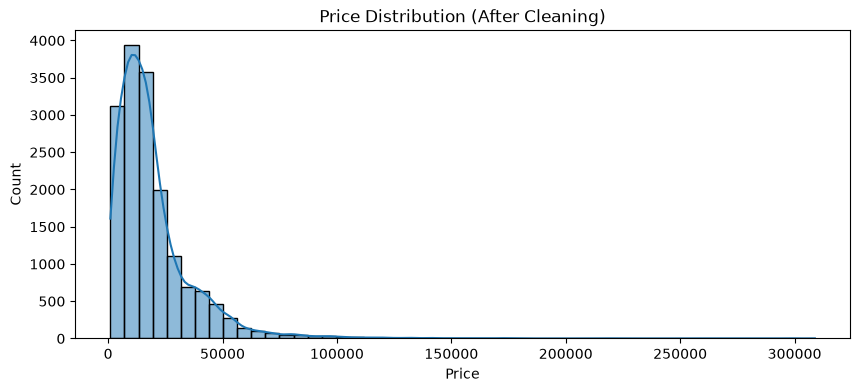

Skewness : 3.684279537858689


In [32]:
print(df['Price'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution (After Cleaning)')
plt.show()

print('Skewness :', df['Price'].skew())

In [33]:
df['Price_log'] = np.log1p(df['Price'])

count    16402.000000
mean         9.537583
std          0.888056
min          6.908755
25%          9.047939
50%          9.637176
75%         10.091998
max         12.640796
Name: Price_log, dtype: float64


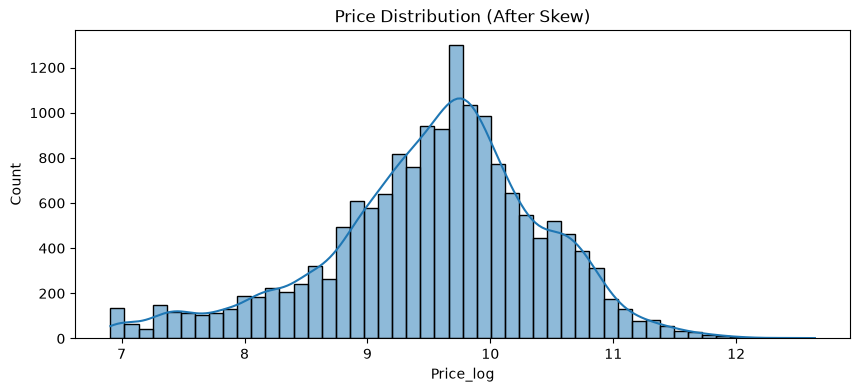

Skewness : -0.4965440851022297


In [34]:
print(df['Price_log'].describe())

plt.figure(figsize=(10,4))
sns.histplot(df['Price_log'], bins=50, kde=True)
plt.title('Price Distribution (After Skew)')
plt.show()

print('Skewness :', df['Price_log'].skew())

In [35]:
len(df[df['Levy'] == '-'])

0

In [36]:
print(df['Levy'].dtype)
print(df['Levy'].unique()[:20])
print(df['Levy'].value_counts().head(10))

str
<ArrowStringArray>
['1399', '1018',    nan,  '862',  '446',  '891',  '761',  '394', '1055',
  '810',  '531',  '586', '1249',  '583', '1537', '1288',  '915',  '707',
 '1077', '1486']
Length: 20, dtype: str
Levy
765     460
891     431
639     375
640     350
707     257
836     249
642     246
781     228
777     228
1017    222
Name: count, dtype: int64


In [37]:
df['Levy'] = df['Levy'].replace('-', np.nan)
df['Levy'] = df['Levy'].astype(float)

print(df['Levy'].dtype)
print(df['Levy'].isnull().sum())
print(df['Levy'].describe())

float64
5331
count    11071.000000
mean       890.678439
std        454.374294
min         87.000000
25%        640.000000
50%        779.000000
75%       1051.000000
max      11714.000000
Name: Levy, dtype: float64


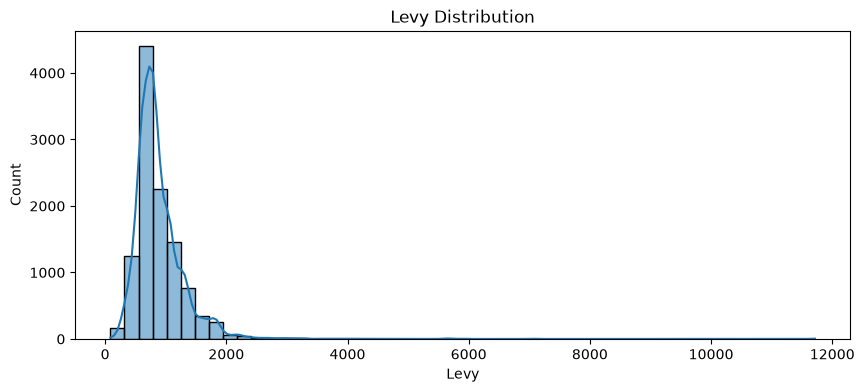

In [38]:
plt.figure(figsize=(10,4))
sns.histplot(df['Levy'].dropna(), bins=50, kde=True)
plt.title('Levy Distribution')
plt.show()

In [39]:
df['Airbags'].value_counts()

Airbags
4     5621
12    4005
0     1691
8     1514
6     1245
2     1010
10     827
5       93
16      91
7       81
1       73
9       59
3       35
11      29
14      20
15       7
13       1
Name: count, dtype: int64

In [40]:
np.sort(df['Prod. year'].unique())

array([1943, 1953, 1957, 1964, 1965, 1968, 1973, 1974, 1977, 1978, 1980,
       1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002,
       2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020])

In [41]:
df['Model'].unique()

<ArrowStringArray>
[                  'Rx 450',                  'Equinox',
                      'Fit',                   'Escape',
                 'Santa Fe',                    'Prius',
                    'Camry',                   'Rx 350',
                  'Transit',                   'Vectra',
 ...
                      'S70',                   'S-Type',
           'Vito Extralong',                'E 500 Avg',
                   'Fit Lx', 'Every Landy Nissan Seren',
                   'Cl 600',                'E 230 124',
           'Rx 450 F Sport',             'Prius C Aqua']
Length: 1478, dtype: str

In [60]:
unique_models = df['Model'].unique().tolist()
len(unique_models)

1478

In [43]:
print(unique_models[:1505])

['Rx 450', 'Equinox', 'Fit', 'Escape', 'Santa Fe', 'Prius', 'Camry', 'Rx 350', 'Transit', 'Vectra', 'Elantra', 'E 220', 'Highlander', 'Vito', 'Cayenne', 'X5', 'Grand Cherokee', 'Chr Limited', 'H1', 'Jetta', 'Sonata', 'Prius C', 'Aqua', 'Escape Hybrid', 'Civic', 'Megane 1.5Cdi', 'Q5', 'C 180', 'Gla 250', 'Juke', 'Cruze Lt', 'Fusion', 'Voxy', 'A 160', 'Tucson', 'Vitz', 'Captiva', 'Mustang', 'Ml 350', 'Yaris', 'Cr-V', 'Cruze', 'Orlando', 'Gl 63 Amg', '520 Vanos', 'Lacetti', '428 Sport Line', 'Patrol', 'E 320', 'Genesis', 'Gx 460', 'Sprinter', 'Focus Se', 'Picanto', '328', 'Explorer', 'Airtrek', 'E 500 Amg', 'Lancer', 'Korando', 'Clio', 'C 220', 'Serena', 'Rav 4', 'Pajero', 'E 300', 'Terrain', '208', 'Hr-V Ex', '500', 'Legacy', 'Elantra Sport Limited', 'Sienna', 'A 170', 'Nx 300', 'Rexton', 'Tacoma', 'Carnival Grand', 'Qx60', 'Passat', 'E 240 E 240', '50', 'C 250', 'Vitz Funkargo', '325', 'Pathfinder', 'Delica', 'Golf', 'Vaneo', 'Camry Se', 'Patrol Y60', 'A7', 'E 350', 'I30', 'Altima', '14

In [61]:
import pandas as pd
import re

def clean_model_name(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z0-9\s-]', '', text)
    return text.strip()

df['Model'] = df['Model'].apply(clean_model_name).str.title()

threshold = 15
frequent_models = df['Model'].value_counts()[lambda x: x >= threshold].index

df['Model'] = df['Model'].apply(lambda x: x if x in frequent_models else 'Other')

print(f" uniqe: {df['Model'].nunique()}")

 uniqe: 150


In [62]:
print(unique_models[:161])

['Rx 450', 'Equinox', 'Fit', 'Escape', 'Santa Fe', 'Prius', 'Camry', 'Rx 350', 'Transit', 'Vectra', 'Elantra', 'E 220', 'Highlander', 'Vito', 'Cayenne', 'X5', 'Grand Cherokee', 'Chr Limited', 'H1', 'Jetta', 'Sonata', 'Prius C', 'Aqua', 'Escape Hybrid', 'Civic', 'Megane 1.5Cdi', 'Q5', 'C 180', 'Gla 250', 'Juke', 'Cruze Lt', 'Fusion', 'Voxy', 'A 160', 'Tucson', 'Vitz', 'Captiva', 'Mustang', 'Ml 350', 'Yaris', 'Cr-V', 'Cruze', 'Orlando', 'Gl 63 Amg', '520 Vanos', 'Lacetti', '428 Sport Line', 'Patrol', 'E 320', 'Genesis', 'Gx 460', 'Sprinter', 'Focus Se', 'Picanto', '328', 'Explorer', 'Airtrek', 'E 500 Amg', 'Lancer', 'Korando', 'Clio', 'C 220', 'Serena', 'Rav 4', 'Pajero', 'E 300', 'Terrain', '208', 'Hr-V Ex', '500', 'Legacy', 'Elantra Sport Limited', 'Sienna', 'A 170', 'Nx 300', 'Rexton', 'Tacoma', 'Carnival Grand', 'Qx60', 'Passat', 'E 240 E 240', '50', 'C 250', 'Vitz Funkargo', '325', 'Pathfinder', 'Delica', 'Golf', 'Vaneo', 'Camry Se', 'Patrol Y60', 'A7', 'E 350', 'I30', 'Altima', '14

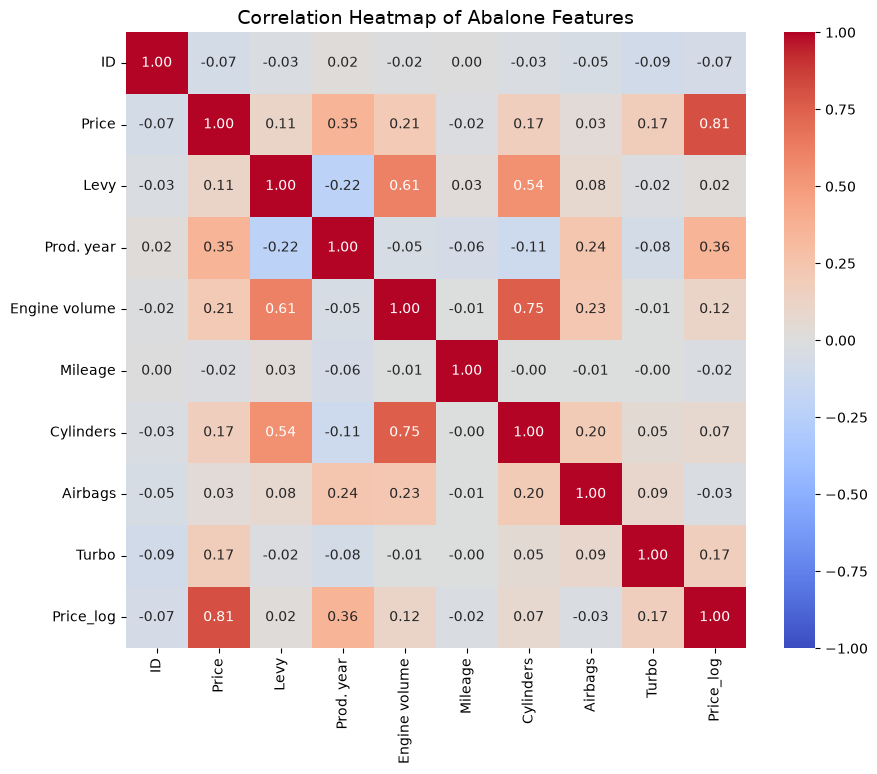

In [64]:
plt.figure(figsize=(10, 8))

# Select only the numeric columns for correlation (drops 'Sex')
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
# Generate the heatmap
sns.heatmap(
    numeric_cols.corr(), 
    annot=True,          # Prints the exact correlation numbers
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    fmt=".2f",           # Rounds numbers to 2 decimal places
    vmin=-1, vmax=1      # Sets the scale from -1 to 1
    ,
)
plt.title("Correlation Heatmap of Abalone Features", fontsize=14)
plt.show()

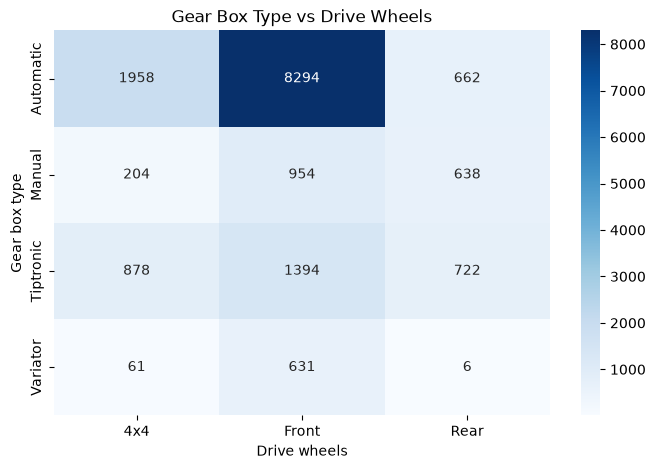

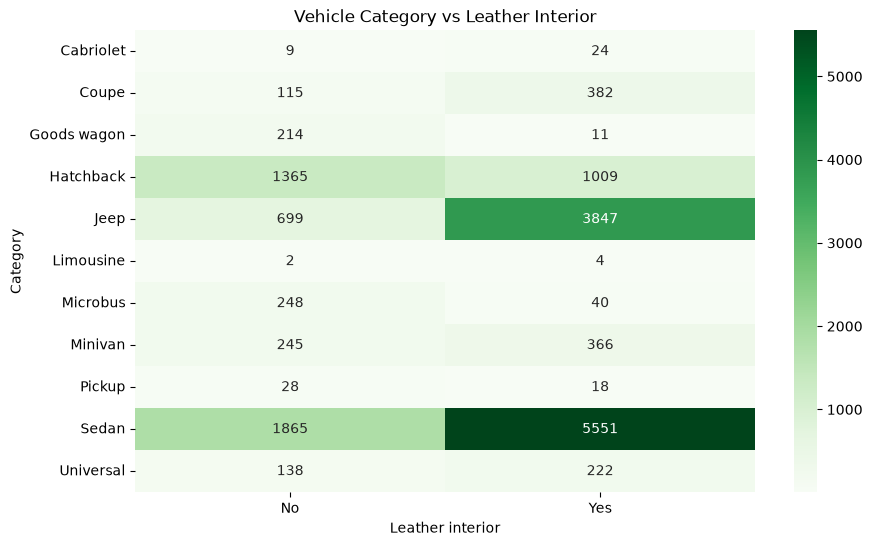

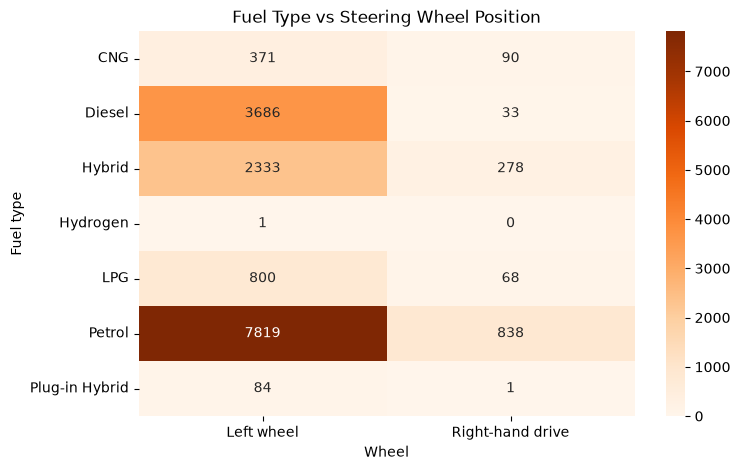

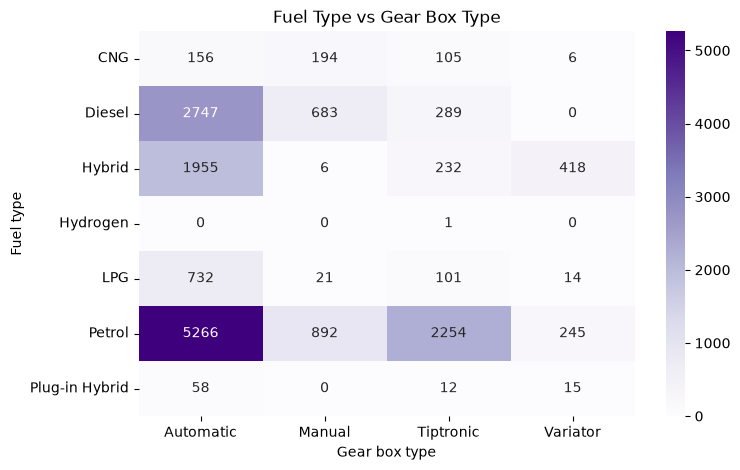

In [70]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.figure(figsize=(8, 5))
ct1 = pd.crosstab(df['Gear box type'], df['Drive wheels'])
sns.heatmap(ct1, annot=True, fmt='d', cmap='Blues')
plt.title('Gear Box Type vs Drive Wheels')
plt.show()

plt.figure(figsize=(10, 6))
ct2 = pd.crosstab(df['Category'], df['Leather interior'])
sns.heatmap(ct2, annot=True, fmt='d', cmap='Greens')
plt.title('Vehicle Category vs Leather Interior')
plt.show()

plt.figure(figsize=(8, 5))
ct3 = pd.crosstab(df['Fuel type'], df['Wheel'])
sns.heatmap(ct3, annot=True, fmt='d', cmap='Oranges')
plt.title('Fuel Type vs Steering Wheel Position')
plt.show()

plt.figure(figsize=(8, 5))
ct4 = pd.crosstab(df['Fuel type'], df['Gear box type'])
sns.heatmap(ct4, annot=True, fmt='d', cmap='Purples')
plt.title('Fuel Type vs Gear Box Type')
plt.show()

In [ ]:
df[ 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],

In [63]:
1# What is your target column and what does it represent?
2# Is your target categorical or continuous? is it balanced (Plot the distribution)?
3# What types of features do you have (categorical / numerical)? how many of each ?
4# How many null values does each feature have? what's your plan for each?
5# Which features are most correlated with your target, and with each other?
6# Are there outliers? how would you handle them?

In [71]:
#                                   car price prediction 

# # 1 #
# Target column: Price , represents the cars selling price, which is the variable we will attempt to predict

# # 2 #
# The target variable is continuous, as this represents a regression problem.Distribution & Balance: For continuous 
# variables, the concept of class balance does not apply; instead, we analyze the shape of the probability
# distribution. The price distribution is heavily right-skewed (positively skewed). This occurs because 
# the majority of vehicles fall within a moderate, standard price range, while a small
# fraction of high-end luxury or rare vehicles create a long tail toward extreme values.Proposed 
# Action:To address this asymmetry and reduce the impact of extreme values, a Log Transformation
# (e.g., $\log(y+1)$) will be applied to normalize the distribution before training the model.

# # 3 # 
# Numerical Features(8):
# Price , Prod. year ,Levy, Engine volumem , Mileage, Cylinders  , Airbags ,ID
# 2. Categorical Features (10) :
# Manufacturer , Model Category  , Leather  , interior ,  Fuel type , Gear box type
# , Drive wheels , Doors , Wheel , Color

# # 4 # 

# no nulls
# # 5 # 
# `Price_log exhibits the strongest correlation with the target Price, 
# followed by Prod. year andEngine volume ,  while Engine volume 
# shows high inter-feature correlation with Cylinders and Levy.
# # 6 # 
# yes Outliers are identified using the IQR method and handled by removing invalid values, capping extreme features at the 1st
#  and 99th
#  percentiles, and applying a log transformation to normalize right-skewed data
# .Outliers were removed by filtering out data points that fall outside the lower (Q1 - 1.5*)and upper (Q3 + 1.5 *IQR) bounds

# Topic 2 : [Bank Marketing]

## Problem Statement

[Making phone calls to all customers for marketing takes a lot of time and costs money, but many customers say no. The goal of this project is to build a machine learning model that predicts if a customer will subscribe to a bank term deposit (yes or no). By predicting who is likely to join, the bank can focus only on interested clients and save time and money]

## Data Info
Data Source :https://archive-beta.ics.uci.edu/dataset/222/bank+marketing



## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| age | int | Age of the client |
| job | object | Type of job (e.g., admin., blue-collar, entrepreneur, technician) |
| marital | object | Marital status (married, single, divorced) |
| education | object | Education level (primary, secondary, tertiary, unknown) |
| default | object | Has credit in default? (yes, no) |
| balance | int | Average yearly balance in euros |
| housing | object | Has a housing loan? (yes, no) |
| loan | object | Has a personal loan? (yes, no) |
| contact | object | Contact communication type (unknown, telephone, cellular) |
| day | int | Last contact day of the month |
| month | object | Last contact month of year (jan, feb, mar, ..., dec) |
| duration | int | Last contact duration in seconds |
| campaign | int | Number of contacts performed during this campaign for this client |
| pdays | int | Number of days after the client was last contacted from a previous campaign (-1 means not previously contacted) |
| previous | int | Number of contacts performed before this campaign for this client |
| poutcome | object | Outcome of the previous marketing campaign (unknown, other, failure, success) |
| y | object | Target variable: Has the client subscribed to a term deposit? (yes, no) |

In [75]:
df2 = pd.read_csv('./New folder/bank-full.csv', sep=';')
df2.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [76]:
df2.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [77]:
df2.shape

(45211, 17)

In [78]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 8.1 MB


In [79]:
df2.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [56]:
df2.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [57]:
df2.duplicated().sum()

np.int64(0)

In [58]:
df2['age'].unique()

array([58, 44, 33, 47, 35, 28, 42, 43, 41, 29, 53, 57, 51, 45, 60, 56, 32,
       25, 40, 39, 52, 46, 36, 49, 59, 37, 50, 54, 55, 48, 24, 38, 31, 30,
       27, 34, 23, 26, 61, 22, 21, 20, 66, 62, 83, 75, 67, 70, 65, 68, 64,
       69, 72, 71, 19, 76, 85, 63, 90, 82, 73, 74, 78, 80, 94, 79, 77, 86,
       95, 81, 18, 89, 84, 87, 92, 93, 88])

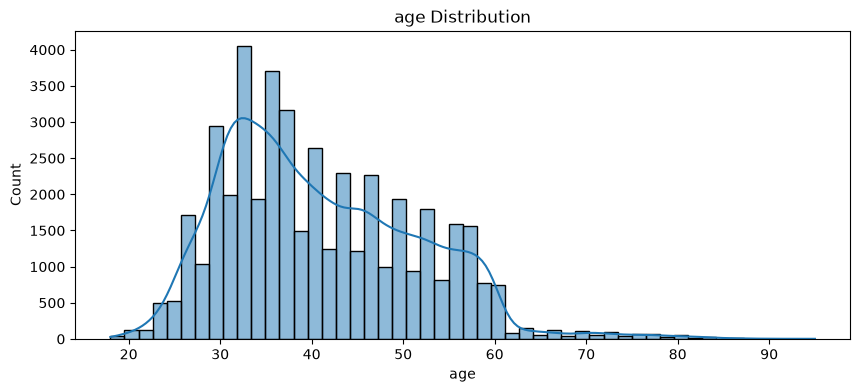

In [59]:
plt.figure(figsize=(10,4))
sns.histplot(df2['age'].dropna(), bins=50, kde=True)
plt.title('age Distribution')
plt.show()

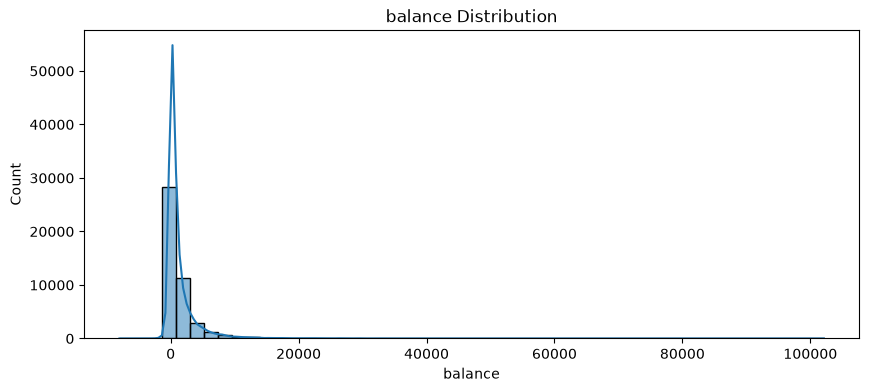

In [60]:
plt.figure(figsize=(10,4))
sns.histplot(df2['balance'].dropna(), bins=50, kde=True)
plt.title('balance Distribution')
plt.show()

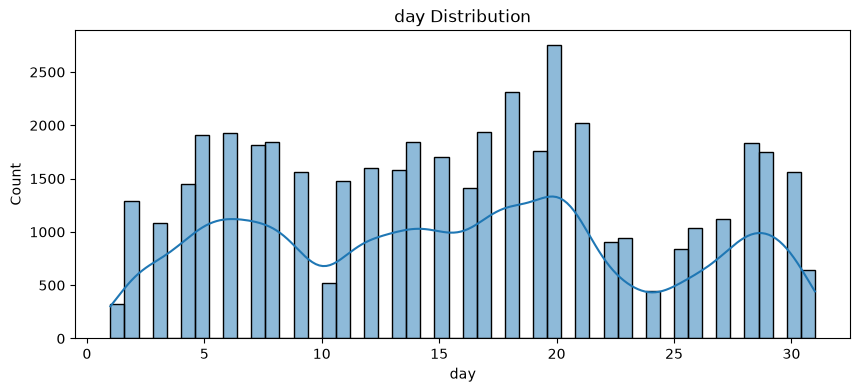

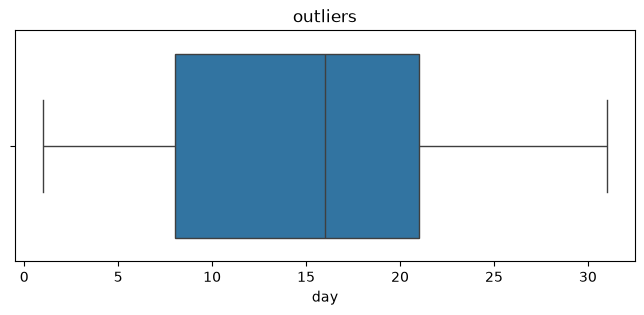

In [61]:
plt.figure(figsize=(10,4))
sns.histplot(df2['day'].dropna(), bins=50, kde=True)
plt.title('day Distribution')
plt.show() 

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['day'])
plt.title('outliers')
plt.show()

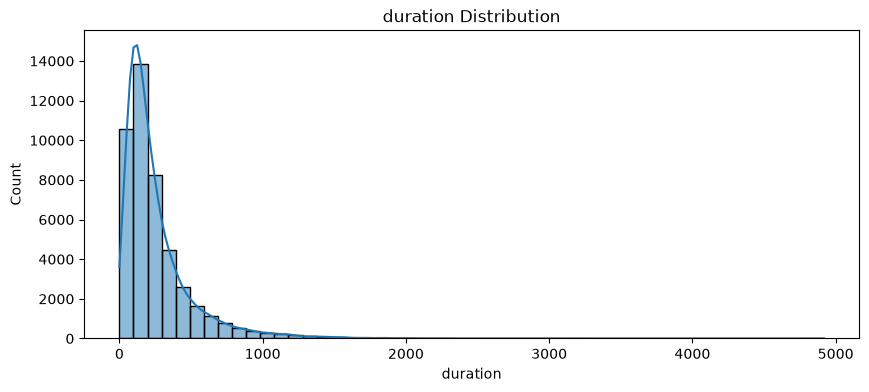

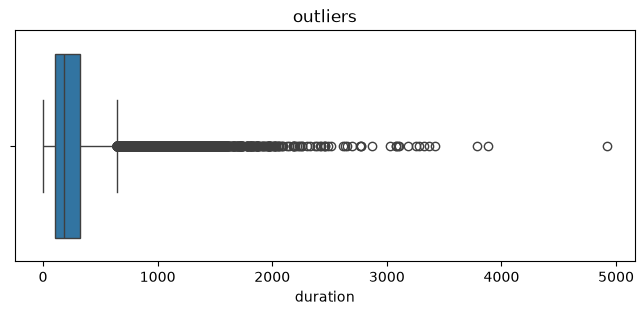

In [62]:
plt.figure(figsize=(10,4))
sns.histplot(df2['duration'].dropna(), bins=50, kde=True)
plt.title('duration Distribution')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['duration'])
plt.title('outliers')
plt.show()

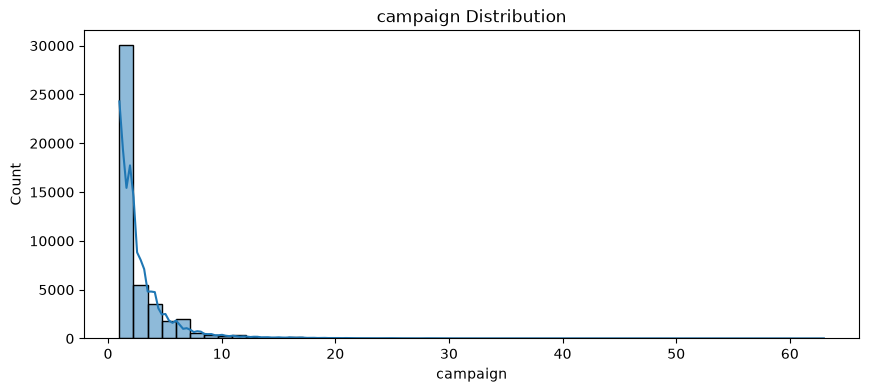

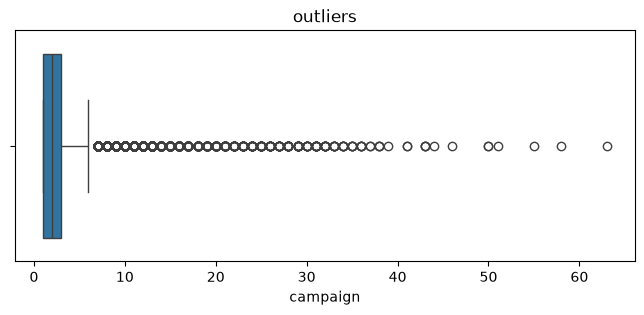

In [63]:
plt.figure(figsize=(10,4))
sns.histplot(df2['campaign'].dropna(), bins=50, kde=True)
plt.title('campaign Distribution')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['campaign'])
plt.title('outliers')
plt.show()

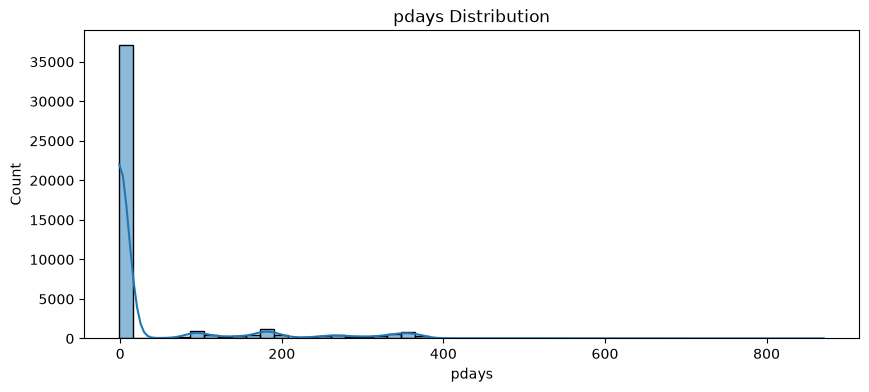

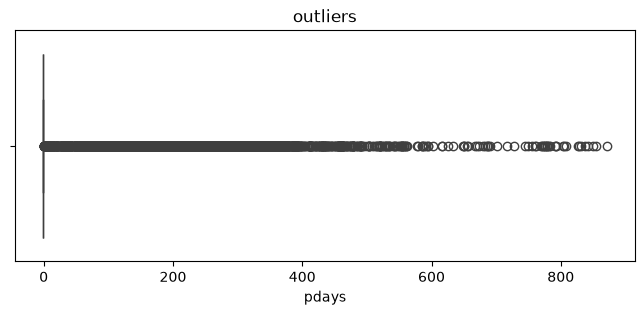

In [64]:
plt.figure(figsize=(10,4))
sns.histplot(df2['pdays'].dropna(), bins=50, kde=True)
plt.title('pdays Distribution')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['pdays'])
plt.title('outliers')
plt.show()

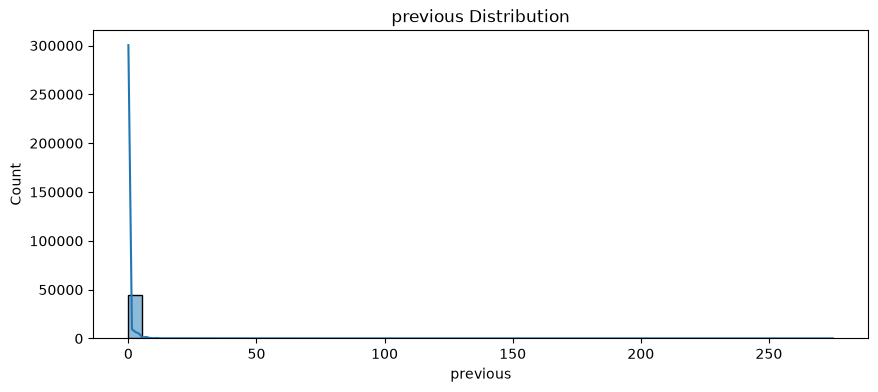

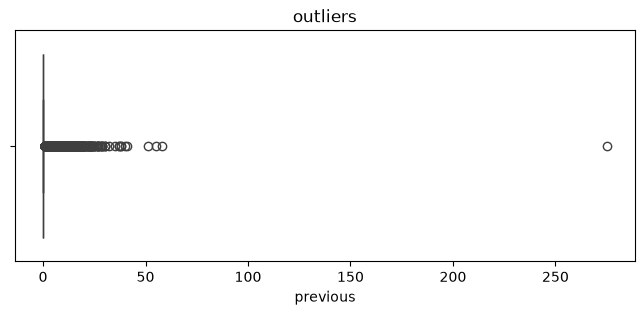

In [65]:
plt.figure(figsize=(10,4))
sns.histplot(df2['previous'].dropna(), bins=50, kde=True)
plt.title('previous Distribution')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['previous'])
plt.title('outliers')
plt.show()

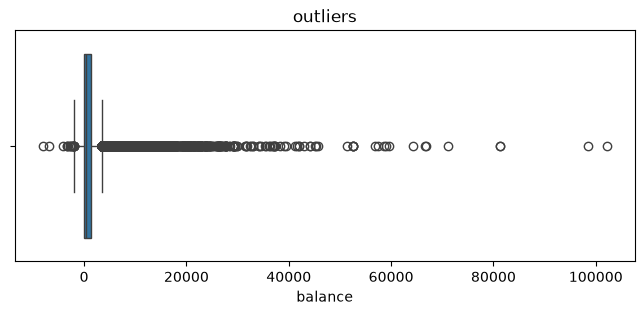

In [66]:
########################################
# شيلي الاوتلايرز
########################################

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['balance'])
plt.title('outliers')
plt.show()

In [67]:
df2['job'].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [68]:
df2['marital'].value_counts()

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

In [69]:
df2['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [70]:
df2['default'].value_counts()

default
no     44396
yes      815
Name: count, dtype: int64

In [71]:
df2['housing'].value_counts()

housing
yes    25130
no     20081
Name: count, dtype: int64

In [72]:
df2['loan'].value_counts()

loan
no     37967
yes     7244
Name: count, dtype: int64

In [73]:
df2['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [74]:
df2['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

In [75]:
df2['poutcome'].value_counts()

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

C:\Users\User\AppData\Local\Temp\ipykernel_7512\3623719004.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df2, x='y', palette='Set2')  # Changed df2 to df


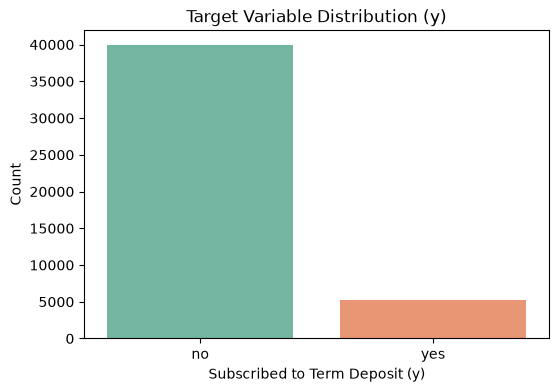

KeyError: 'y'

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df2, x='y', palette='Set2')  # Changed df2 to df
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Count')
plt.show()

# Class percentages
print(df['y'].value_counts(normalize=True) * 100)

In [349]:
1# What is your target column and what does it represent?
2# Is your target categorical or continuous? is it balanced (Plot the distribution)?
3# What types of features do you have (categorical / numerical)? how many of each ?
4# How many null values does each feature have? what's your plan for each?
5# Which features are most correlated with your target, and with each other?
6# Are there outliers? how would you handle them?

In [ ]:
#                                   car price prediction 

# # 1 #
# Target column: y , It represents whether the client subscribed to a term deposit ("yes" or "no").

# # 2 #
# Categorical
# Balance Status: Highly Imbalanced (the vast majority of clients said )

# # 3 # 
# Numerical Features(8):
# Price , Prod. year ,Levy, Engine volumem , Mileage, Cylinders  , Airbags ,ID
# 2. Categorical Features (10) :
# Manufacturer , Model Category  , Leather  , interior ,  Fuel type , Gear box type
# , Drive wheels , Doors , Wheel , Color

# # 4 # 

# no nulls
# # 5 # 
# `Price_log exhibits the strongest correlation with the target Price, 
# followed by Prod. year andEngine volume ,  while Engine volume 
# shows high inter-feature correlation with Cylinders and Levy.
# # 6 # 
# yes Outliers are identified using the IQR method and handled by removing invalid values, capping extreme features at the 1st
#  and 99th
#  percentiles, and applying a log transformation to normalize right-skewed data
# .Outliers were removed by filtering out data points that fall outside the lower (Q1 - 1.5*)and upper (Q3 + 1.5 *IQR) bounds

# Topic 3 : [Default of Credit Card Clients]

## Problem Statement

[When credit card clients default on their payments, banks lose a lot of money and face financial risk. The goal of this project is to build a machine learning model to predict whether a client will default on their credit card payment next month based on their demographic features and payment history. Predicting defaults helps banks reduce financial risk and manage credit better.]

## Data Info
Data Source :https://archive-beta.ics.uci.edu/dataset/350/default+of+credit+card+clients

## Data Dictionary
| Column | Type | Description |
| ------ | ---- | ----------- |
| LIMIT_BAL | float | Amount of given credit in NT dollars (includes individual and family/supplementary credit) |
| SEX | int | Gender (1 = male, 2 = female) |
| EDUCATION | int | Education level (1 = graduate school, 2 = university, 3 = high school, 4 = others, 5/6 = unknown) |
| MARRIAGE | int | Marital status (1 = married, 2 = single, 3 = others) |
| AGE | int | Age in years |
| PAY_0 | int | Repayment status in September (-1 = pay duly, 1 = payment delay for one month, 2 = payment delay for two months, ..., 8 = payment delay for eight months, 9 = payment delay for nine months and above) |
| PAY_2 | int | Repayment status in August (scale same as PAY_0) |
| PAY_3 | int | Repayment status in July (scale same as PAY_0) |
| PAY_4 | int | Repayment status in June (scale same as PAY_0) |
| PAY_5 | int | Repayment status in May (scale same as PAY_0) |
| PAY_6 | int | Repayment status in April (scale same as PAY_0) |
| BILL_AMT1 | float | Amount of bill statement in September (NT dollar) |
| BILL_AMT2 | float | Amount of bill statement in August (NT dollar) |
| BILL_AMT3 | float | Amount of bill statement in July (NT dollar) |
| BILL_AMT4 | float | Amount of bill statement in June (NT dollar) |
| BILL_AMT5 | float | Amount of bill statement in May (NT dollar) |
| BILL_AMT6 | float | Amount of bill statement in April (NT dollar) |
| PAY_AMT1 | float | Amount of previous payment in September (NT dollar) |
| PAY_AMT2 | float | Amount of previous payment in August (NT dollar) |
| PAY_AMT3 | float | Amount of previous payment in July (NT dollar) |
| PAY_AMT4 | float | Amount of previous payment in June (NT dollar) |
| PAY_AMT5 | float | Amount of previous payment in May (NT dollar) |
| PAY_AMT6 | float | Amount of previous payment in April (NT dollar) |
| default payment next month | int | Target variable: Default payment status next month (1 = default, 0 = no default)

In [78]:
df3 = pd.read_csv('./New folder/defaultofcreditcardclients.csv' , header=1, index_col=0)
df3.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
ID,,,,,,,,,,,,,,,,,,,,,
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [79]:
df3.shape

(30000, 24)

In [80]:
df3.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='str')

In [81]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   LIMIT_BAL                   30000 non-null  int64
 1   SEX                         30000 non-null  int64
 2   EDUCATION                   30000 non-null  int64
 3   MARRIAGE                    30000 non-null  int64
 4   AGE                         30000 non-null  int64
 5   PAY_0                       30000 non-null  int64
 6   PAY_2                       30000 non-null  int64
 7   PAY_3                       30000 non-null  int64
 8   PAY_4                       30000 non-null  int64
 9   PAY_5                       30000 non-null  int64
 10  PAY_6                       30000 non-null  int64
 11  BILL_AMT1                   30000 non-null  int64
 12  BILL_AMT2                   30000 non-null  int64
 13  BILL_AMT3                   30000 non-null  int64
 14  BILL_AMT4        

In [82]:
df3.isna().sum()

LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

In [83]:
df3.describe()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [84]:
df3.duplicated().sum()

np.int64(35)

In [85]:
df3 =df3.drop_duplicates().reset_index(drop=True)
df3.duplicated().sum()

np.int64(0)

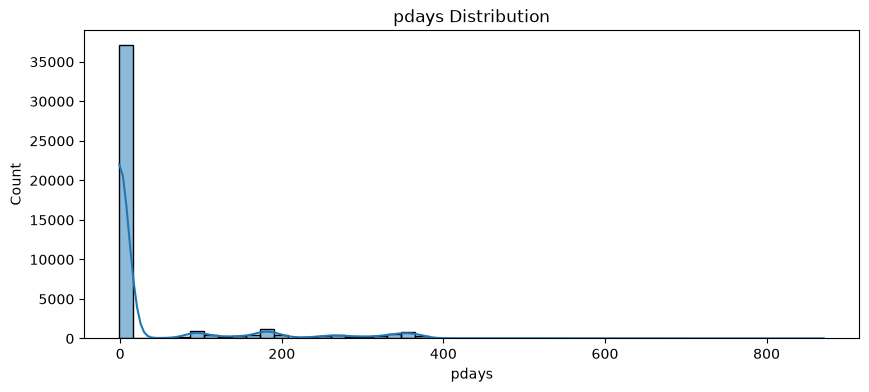

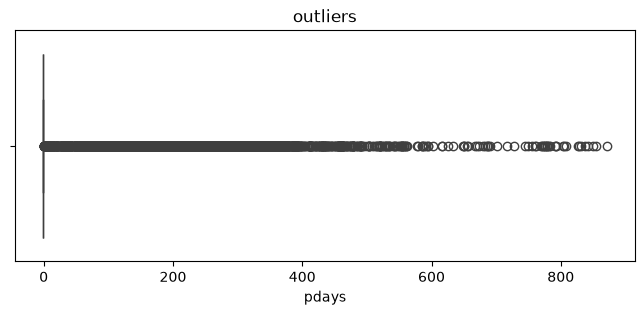

In [86]:
plt.figure(figsize=(10,4))
sns.histplot(df2['pdays'].dropna(), bins=50, kde=True)
plt.title('pdays Distribution')
plt.show()

plt.figure(figsize=(8, 3))
sns.boxplot(x=df2['pdays'])
plt.title('outliers')
plt.show()

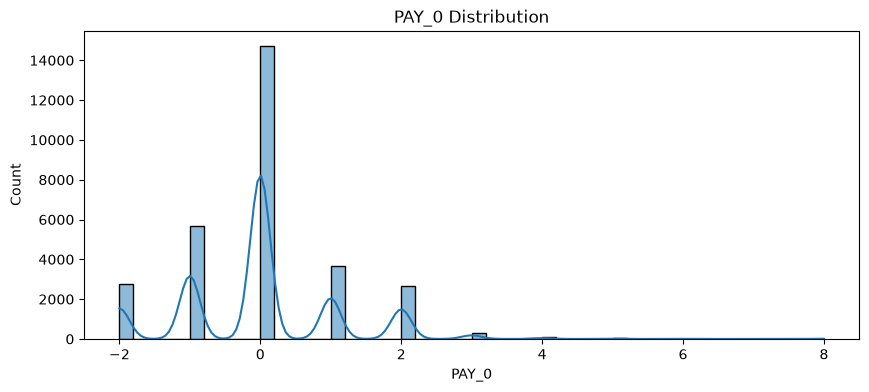

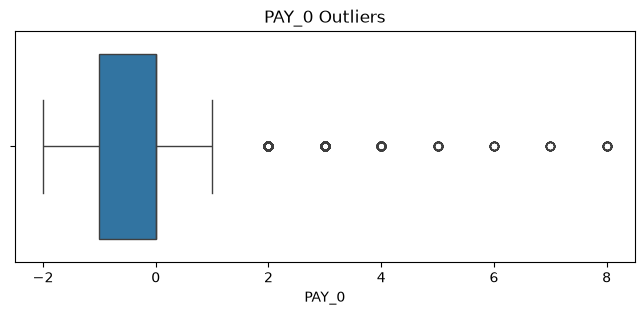

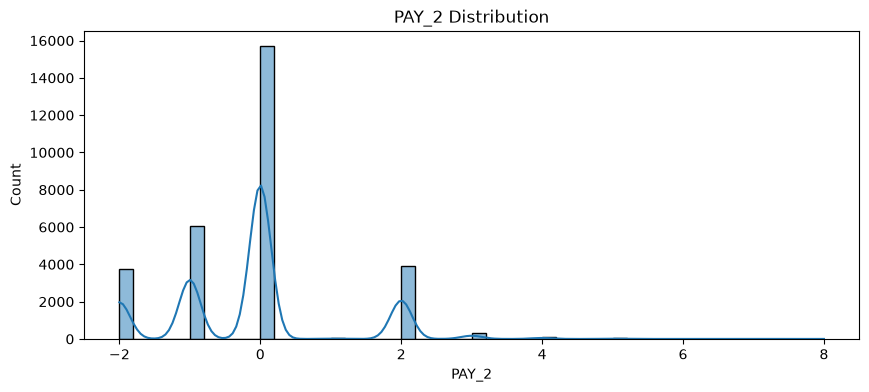

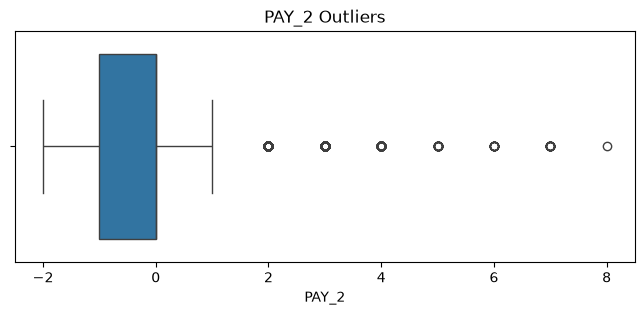

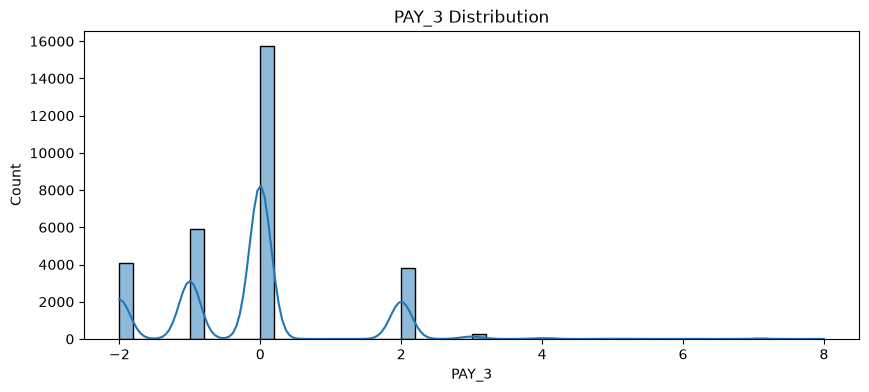

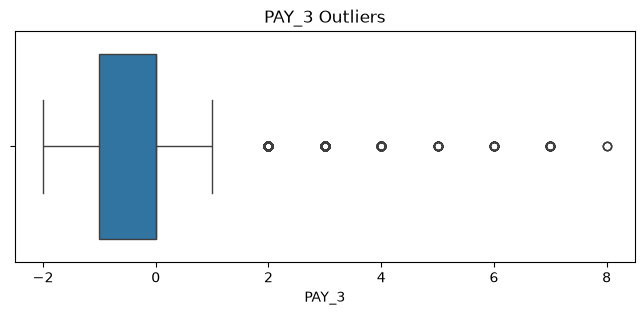

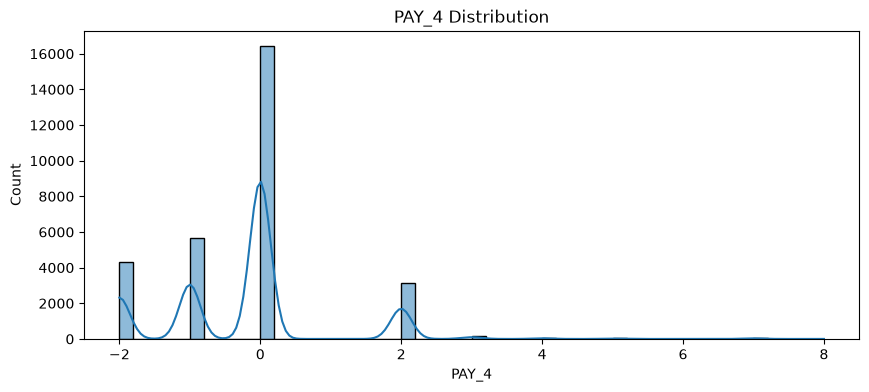

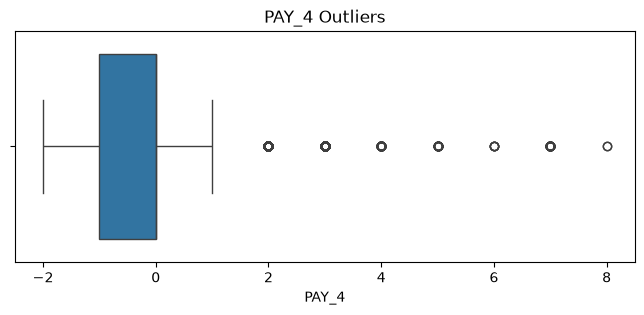

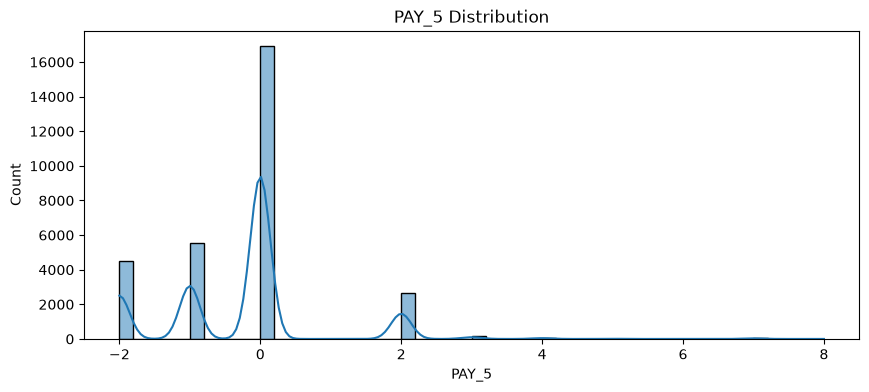

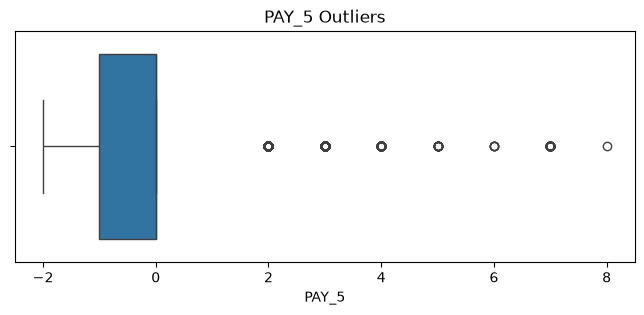

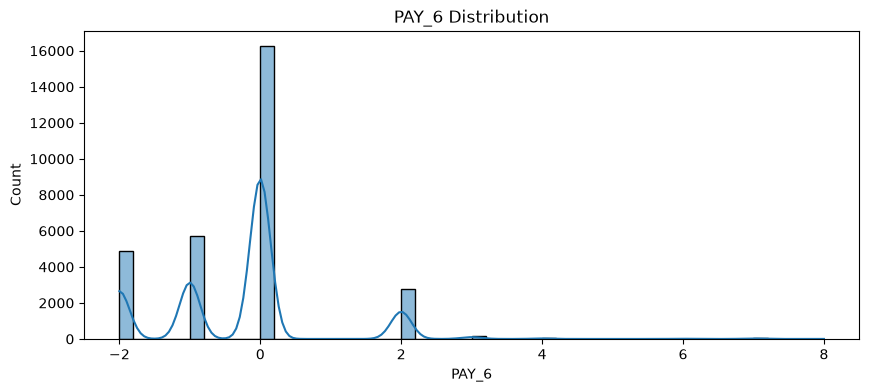

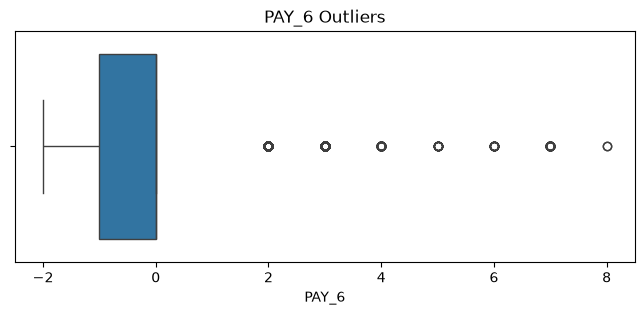

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_cols = [c for c in df3.columns if c.startswith('PAY_') and not c.startswith('PAY_AMT')]

for col_name in pay_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df3[col_name].dropna(), bins=50, kde=True)
    plt.title(f'{col_name} Distribution')
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df3[col_name])
    plt.title(f'{col_name} Outliers')
    plt.show()

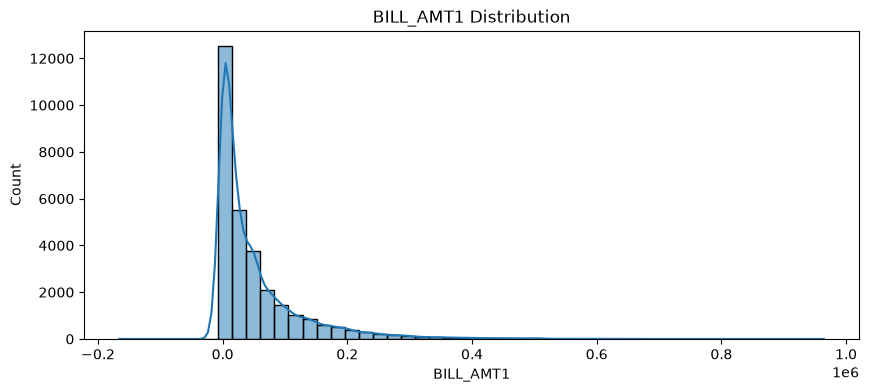

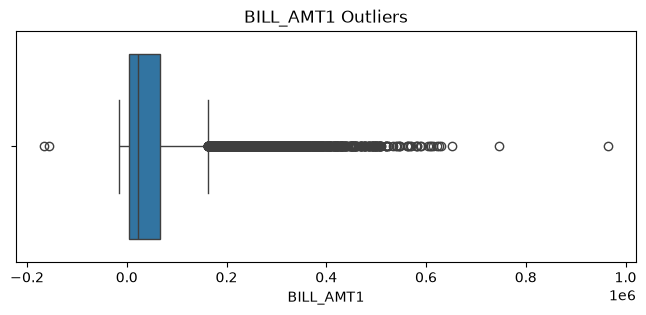

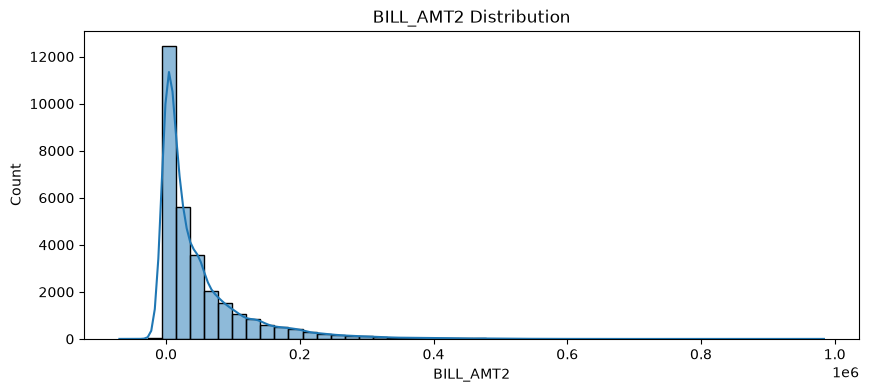

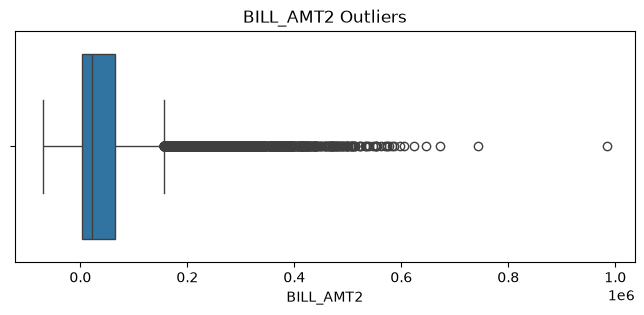

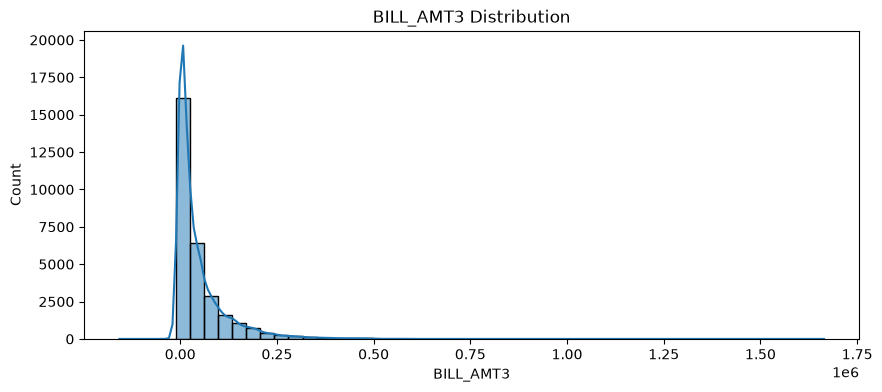

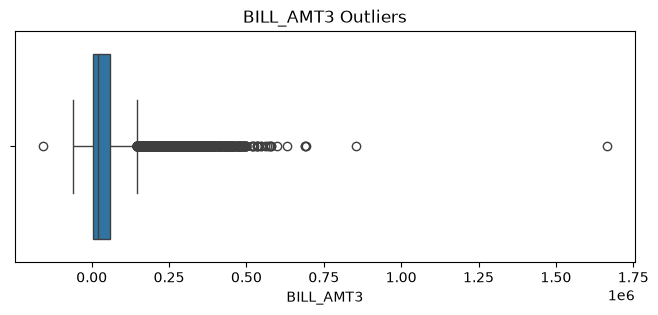

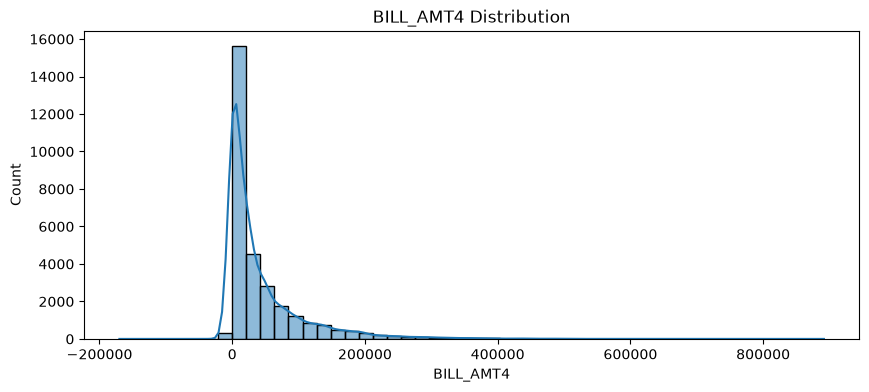

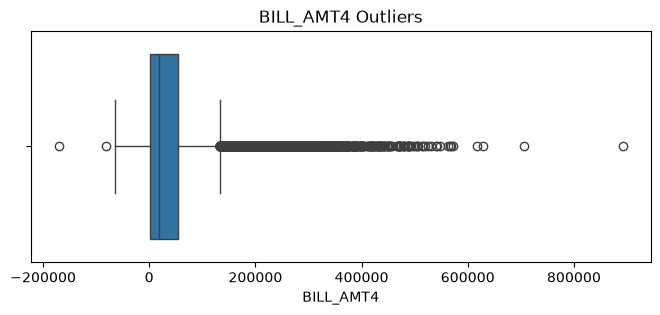

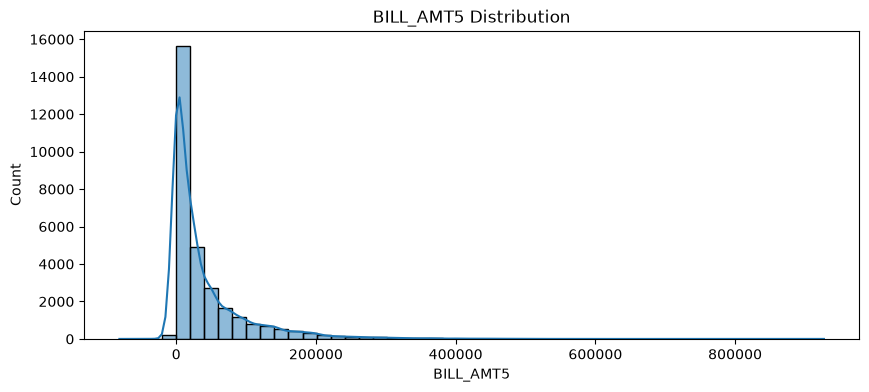

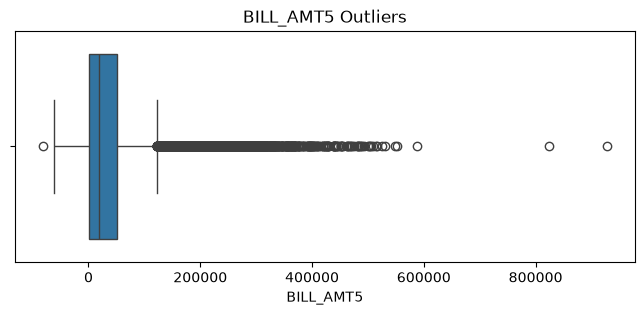

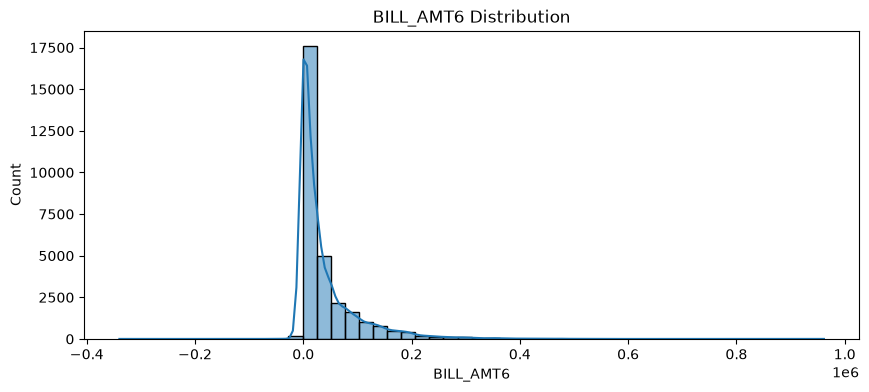

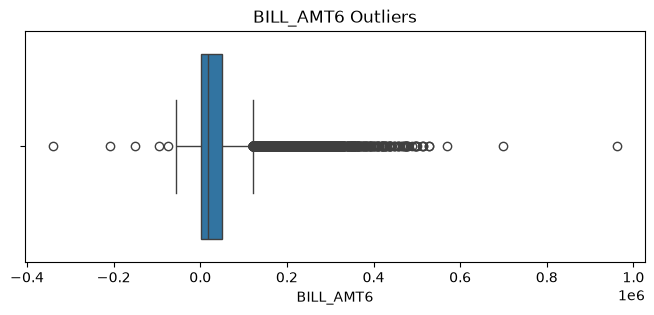

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

pay_cols = [c for c in df3.columns if c.startswith('BILL_AMT') and not c.startswith('PAY_AMT')]

for col_name in pay_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df3[col_name].dropna(), bins=50, kde=True)
    plt.title(f'{col_name} Distribution')
    plt.show()

    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df3[col_name])
    plt.title(f'{col_name} Outliers')
    plt.show()

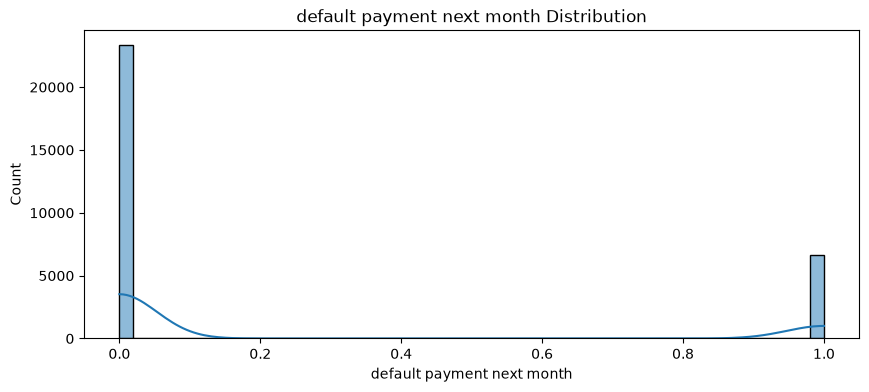

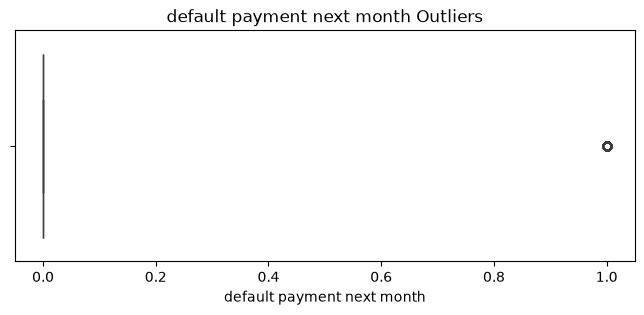

In [89]:
    

plt.figure(figsize=(10, 4))
sns.histplot(df3['default payment next month'].dropna(), bins=50, kde=True)
plt.title(f'{'default payment next month'} Distribution')
plt.show()
    
plt.figure(figsize=(8, 3))
sns.boxplot(x=df3['default payment next month'])
plt.title(f'{'default payment next month'} Outliers')
plt.show()

In [390]:
# What is your target column and what does it represent?
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

SyntaxError: incomplete input (1705199210.py, line 2)